CLUSTERING K-MEANS

In [2]:
%matplotlib inline
from sklearn.datasets import make_blobs
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
import numpy as np
from sklearn.cluster import KMeans, AgglomerativeClustering

# use seaborn plotting defaults
import seaborn as sns; sns.set_theme()
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

In [3]:
#Cargar datos
path = os.path.join('df_final.csv')
df = pd.read_csv(path)

In [4]:
# Seleccionar solo columnas numéricas
df_numericas = df.select_dtypes(include = np.number)
print("Variables numéricas:", df_numericas.shape)

Variables numéricas: (53747, 17)


In [6]:
# ==========================================
# 3. VISUALIZACIÓN EN 2D (PCA)
# ==========================================
from sklearn.decomposition import PCA
def plot_clusters(df_numericas, labels, title):
    pca = PCA(n_components=2)
    X2 = pca.fit_transform(df_numericas)

    plt.figure(figsize=(7,5))
    sns.scatterplot(x=X2[:,0], y=X2[:,1], hue=labels, palette="tab10", s=45)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.show()

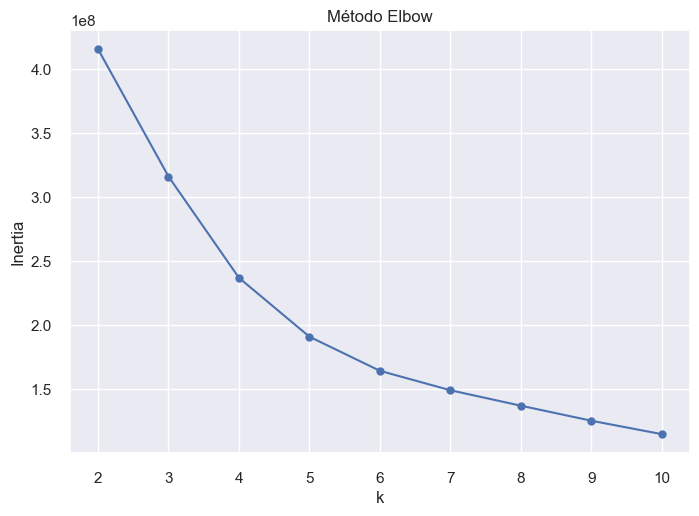

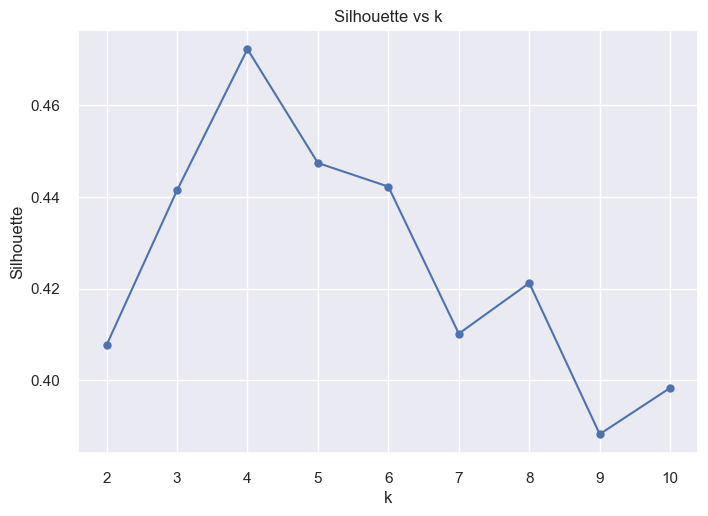

In [7]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# ==========================================
# 4. K-MEANS: ELBOW + SILHOUETTE
# ==========================================
k_values = range(2, 11)
inertias = []
silhouettes = []

for k in k_values:
    modelo = KMeans(n_clusters=k, n_init=10, random_state=42)
    etiquetas = modelo.fit_predict(df_numericas)
    inertias.append(modelo.inertia_)
    silhouettes.append(silhouette_score(df_numericas, etiquetas))

# ----- Elbow -----
plt.plot(k_values, inertias, '-o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Método Elbow")
plt.show()

# ----- Silhouette -----
plt.plot(k_values, silhouettes, '-o')
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.title("Silhouette vs k")
plt.show()



=== Métricas K-Means ===
{'Silhouette': np.float64(0.4473899571736851), 'Davies-Bouldin': np.float64(0.8329465166662068), 'Calinski-Harabasz': np.float64(30682.16682175056)}


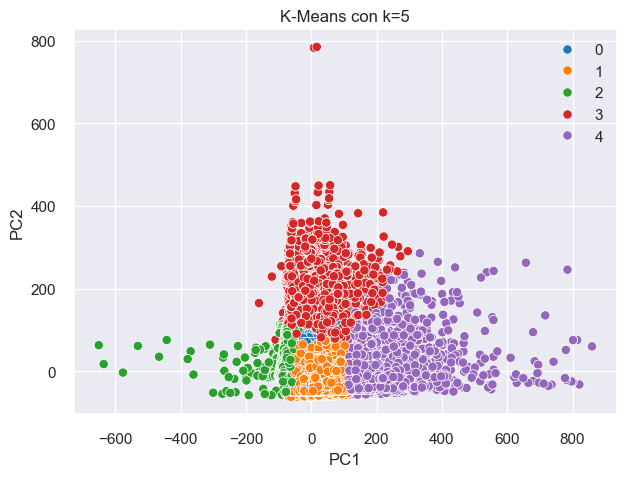

In [8]:
# ==========================================
# 5. K-MEANS FINAL (elige tú el k)
# ==========================================
k_final = 5  # <-- modifica según elbow/silhouette
kmeans = KMeans(n_clusters = k_final, n_init = 10, random_state = 42)
labels_kmeans = kmeans.fit_predict(df_numericas)

print("\n=== Métricas K-Means ===")
print(evaluar_clustering(df_numericas, labels_kmeans))

plot_clusters(df_numericas, labels_kmeans, f"K-Means con k = {k_final}")

CLUSTERING JERÁRQUICO:

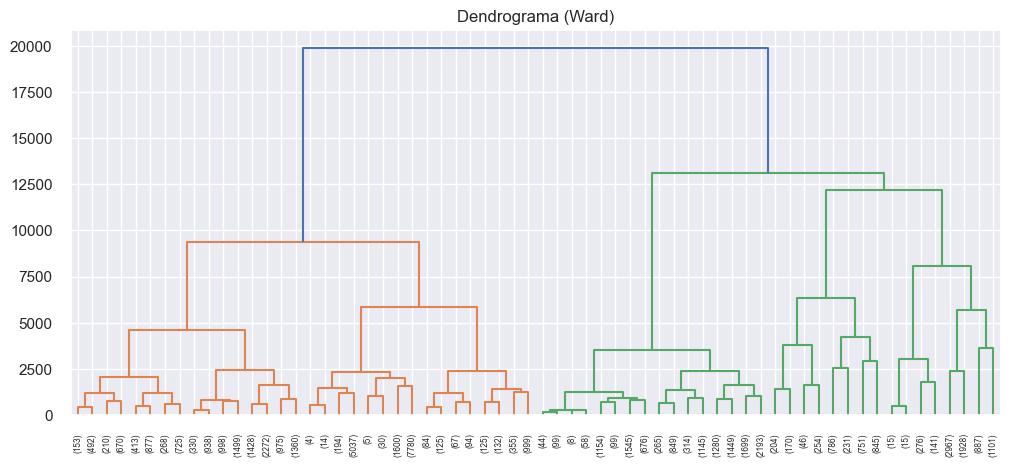

In [9]:
from scipy.cluster.hierarchy import dendrogram, linkage
# ==========================================
# 6. CLUSTERING JERÁRQUICO (WARD)
# ==========================================
# ----- Dendrograma -----
Z = linkage(df_numericas, method = 'ward')

plt.figure(figsize=(12,5))
dendrogram(Z, truncate_mode='level', p=5)
plt.title("Dendrograma (Ward)")
plt.show()


=== Métricas Jerárquico (Ward) ===
{'Silhouette': np.float64(0.3880711325627126), 'Davies-Bouldin': np.float64(1.0343976451002799), 'Calinski-Harabasz': np.float64(23778.071082728384)}


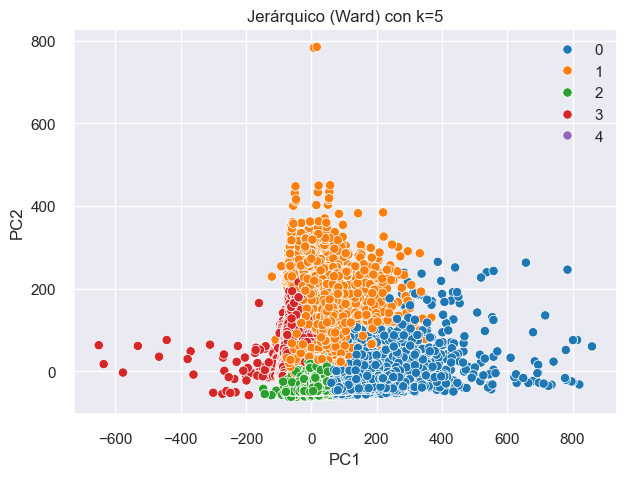

In [ ]:
# ==========================================
# 7. JERÁRQUICO FINAL (elige número de clusters)
# ==========================================
k_hier = 5  # <-- decide cortando el dendrograma
jerarquico = AgglomerativeClustering(n_clusters = k_hier, linkage = 'ward')
labels_hier = jerarquico.fit_predict(df_numericas)

print("\n=== Métricas Jerárquico (Ward) ===")
print(evaluar_clustering(df_numericas, labels_hier))

plot_clusters(df_numericas, labels_hier, f'Clustering Jerárquico (Ward) con k = {k_hier}')

In [ ]:
# ==========================================
# 2. FUNCIONES DE EVALUACIÓN
# ==========================================
def evaluar_clustering(df_numericas, etiquetas):
    """Devuelve métricas para comparar particiones."""
    silhouette = silhouette_score(df_numericas, etiquetas)
    db = davies_bouldin_score(df_numericas, etiquetas)
    ch = calinski_harabasz_score(df_numericas, etiquetas)

    return {
        "Silhouette": silhouette,
        "Davies-Bouldin": db,
        "Calinski-Harabasz": ch
    }

ÍNDICE DE SILUETA:
- De -1 a 1
- Cuanto más alto, mejor

ÍNDICE DAVIES-BOULDIN (DBI):
- de 0 a ∞
- Cuanto más bajo, mejor

ÍNDICE CALINSKI-HARABASZ (CH):
- No hay escala fija
- Cuanto más alto, mejor

In [11]:
# ==========================================
# 8. COMPARACIÓN FINAL
# ==========================================
print("\n===== COMPARACIÓN FINAL =====")
print("K-MEANS:", evaluar_clustering(df_numericas, labels_kmeans))
print("JERÁRQUICO:", evaluar_clustering(df_numericas, labels_hier))


===== COMPARACIÓN FINAL =====
K-MEANS: {'Silhouette': np.float64(0.4473899571736851), 'Davies-Bouldin': np.float64(0.8329465166662068), 'Calinski-Harabasz': np.float64(30682.16682175056)}
JERÁRQUICO: {'Silhouette': np.float64(0.3880711325627126), 'Davies-Bouldin': np.float64(1.0343976451002799), 'Calinski-Harabasz': np.float64(23778.071082728384)}
